In [1]:
!pip install opencv-python albumentations matplotlib tqdm

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import albumentations as A
import matplotlib.pyplot as plt

In [ ]:
BASE_DIR = r"masukan_alamat_direktori"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

OUTPUT_DIR = r"masukan_alamat_direktori"
TRAIN_OUT = os.path.join(OUTPUT_DIR, "train")
TEST_OUT  = os.path.join(OUTPUT_DIR, "test")

VISUAL_DIR = os.path.join(OUTPUT_DIR, "Visualisasi")

os.makedirs(TRAIN_OUT, exist_ok=True)
os.makedirs(TEST_OUT, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

In [4]:
IMG_SIZE = (224, 224)

In [5]:
def resize_image(img):
    return cv2.resize(img, IMG_SIZE)

In [6]:
def visualize_resize(img):

    resized = resize_image(img)
    fig, ax = plt.subplots(1,2, figsize=(10,5))

    ax[0].imshow(img)
    ax[0].set_title(f"Original\n{img.shape[1]} x {img.shape[0]}")
    ax[0].axis("off")

    ax[1].imshow(resized)
    ax[1].set_title(f"Resize\n{IMG_SIZE[0]} x {IMG_SIZE[1]}")
    ax[1].axis("off")

    plt.tight_layout()

    save_path = os.path.join(VISUAL_DIR, "resize.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [7]:
def noise_reduction(img):
    return cv2.GaussianBlur(img, (5,5), 0)

In [8]:
def visualize_noise(img):

    resized = resize_image(img)
    denoise = noise_reduction(resized)
    fig, ax = plt.subplots(1,2, figsize=(10,5))

    ax[0].imshow(resized)
    ax[0].set_title("Before Noise Reduction")
    ax[0].axis("off")

    ax[1].imshow(denoise)
    ax[1].set_title("Gaussian Blur")
    ax[1].axis("off")

    plt.tight_layout()

    save_path = os.path.join(VISUAL_DIR, "noise_reduction.jpg")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [9]:
def normalize_image(img):
    return img / 255.0

In [10]:
def visualize_normalization(img):

    resized = resize_image(img)

    normalized = normalize_image(resized)
    fig, ax = plt.subplots(2,2, figsize=(12,8))

    ax[0,0].imshow(resized)
    ax[0,0].set_title("Before Normalization")
    ax[0,0].axis("off")

    ax[0,1].imshow(normalized)
    ax[0,1].set_title("After Normalization")
    ax[0,1].axis("off")

    ax[1,0].hist(resized.ravel(), bins=256)
    ax[1,0].set_title("Pixel Value (0-255)")
    ax[1,0].set_xlim([0,255])

    ax[1,1].hist(normalized.ravel(), bins=256)
    ax[1,1].set_title("Pixel Value (0-1)")
    ax[1,1].set_xlim([0,1])

    plt.tight_layout()

    save_path = os.path.join(VISUAL_DIR, "normalization.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [11]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2)
])

In [12]:
def save_image(img, save_path):

    img_save = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2BGR
    )
    cv2.imwrite(save_path, img_save)

In [13]:
def visualize_augmentation(img):

    resized = resize_image(img)
    resized = noise_reduction(resized)
    resized = normalize_image(resized)

    flip = A.HorizontalFlip(p=1)

    rotate = A.Rotate(limit=20, p=1)

    brightness = A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3,
        p=1
    )

    blur = A.GaussianBlur(
        blur_limit=(3,5),
        p=1
    )

    imgs = [
        resized,
        flip(image=(resized*255).astype(np.uint8))["image"]/255,
        rotate(image=(resized*255).astype(np.uint8))["image"]/255,
        brightness(image=(resized*255).astype(np.uint8))["image"]/255,
        blur(image=(resized*255).astype(np.uint8))["image"]/255
    ]

    titles = [
        "Original",
        "Horizontal Flip",
        "Rotation",
        "Brightness",
        "Gaussian Blur"
    ]

    fig, ax = plt.subplots(1,5, figsize=(20,5))

    for i in range(5):
        ax[i].imshow(imgs[i])
        ax[i].set_title(titles[i], fontsize=10)
        ax[i].axis("off")

    plt.tight_layout()

    save_path = os.path.join(VISUAL_DIR, "augmentation.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [15]:
def preprocess_and_save(
    input_dir,
    output_dir,
    augment_data=False
):
    for class_name in os.listdir(input_dir):
        class_path = os.path.join(
            input_dir,
            class_name
        )
        if not os.path.isdir(class_path):
            continue
        save_class_path = os.path.join(
            output_dir,
            class_name
        )
        os.makedirs(
            save_class_path,
            exist_ok=True
        )
        for img_name in tqdm(
            os.listdir(class_path),
            desc=class_name
        ):
            img_path = os.path.join(
                class_path,
                img_name
            )
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )
            img = resize_image(img)
            img = noise_reduction(img)
            base_name = os.path.splitext(
                img_name
            )[0]
            save_image(
                img,
                os.path.join(
                    save_class_path,
                    f"{base_name}.jpg"
                )
            )
            if augment_data:
                img_uint8 = img.copy()
                augmentations = {
                    "flip":
                    A.HorizontalFlip(p=1),
                    "rotate":
                    A.Rotate(limit=20, p=1),
                    "bright":
                    A.RandomBrightnessContrast(
                        brightness_limit=0.3,
                        contrast_limit=0.3,
                        p=1
                    ),
                    "blur":
                    A.GaussianBlur(
                        blur_limit=(3,5),
                        p=1
                    )
                }
                for aug_name, aug in augmentations.items():
                    aug_img = aug(
                        image=img_uint8
                    )["image"]
                    aug_img = aug_img.astype(np.uint8)
                    save_image(
                        aug_img,
                        os.path.join(
                            save_class_path,
                            f"{base_name}_{aug_name}.jpg"
                        )
                    )

In [16]:
preprocess_and_save(
    input_dir=TRAIN_DIR,
    output_dir=TRAIN_OUT,
    augment_data=True
)

target_spot: 100%|███████████████████████████████████████████████████████████████████| 600/600 [00:07<00:00, 76.13it/s]


In [17]:
preprocess_and_save(
    input_dir=TEST_DIR,
    output_dir=TEST_OUT,
    augment_data=False
)

target_spot: 100%|██████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 279.49it/s]


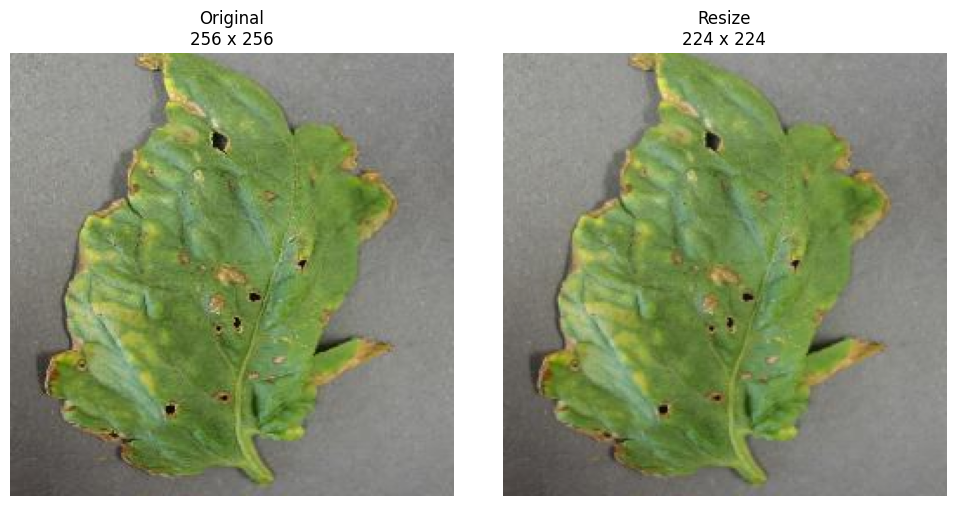

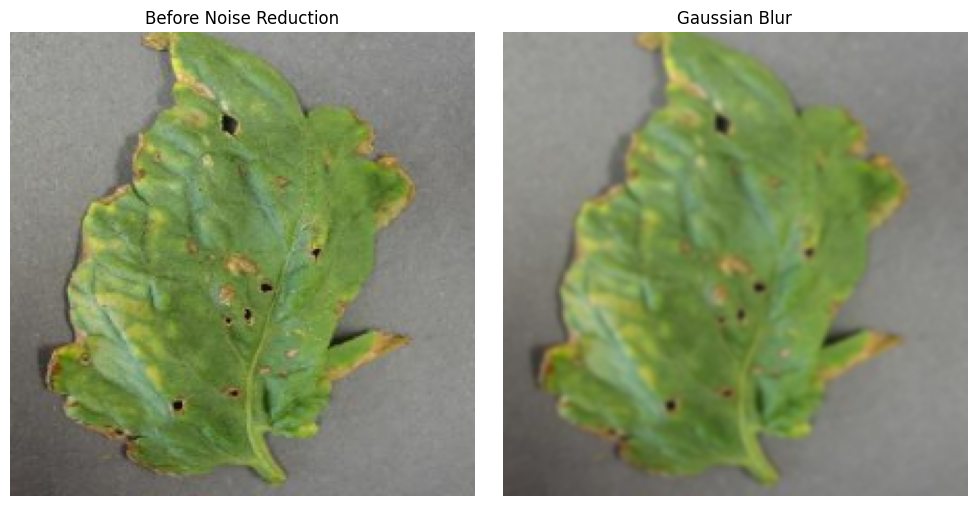

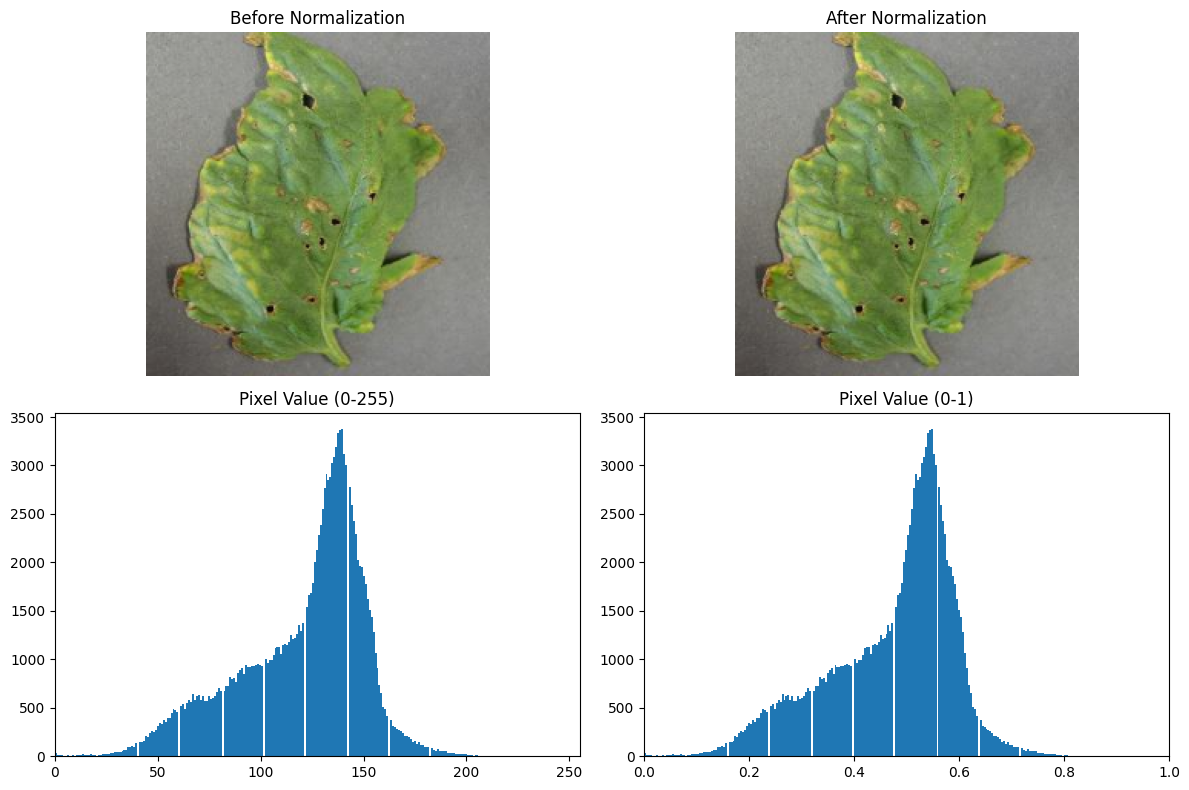

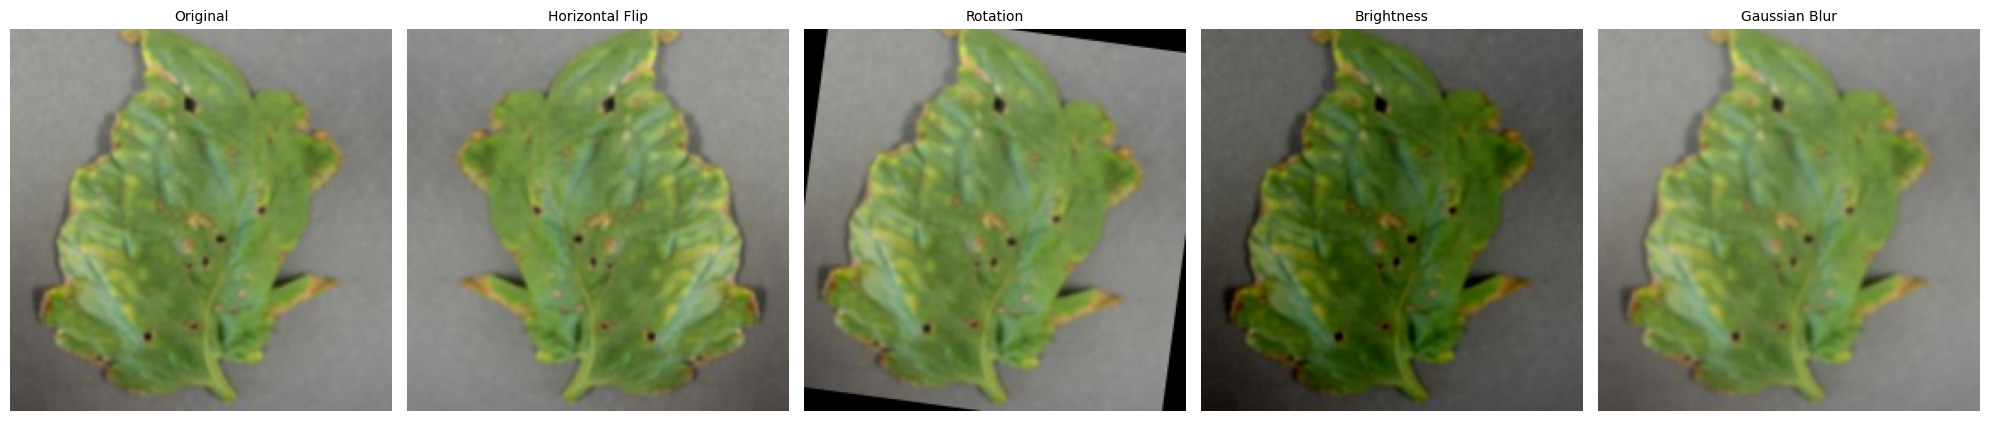

In [18]:
sample_class = os.listdir(TRAIN_DIR)[0]
sample_img = os.listdir(os.path.join(TRAIN_DIR, sample_class))[0]

sample_path = os.path.join(TRAIN_DIR, sample_class, sample_img)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

visualize_resize(img)
visualize_noise(img)
visualize_normalization(img)
visualize_augmentation(img)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

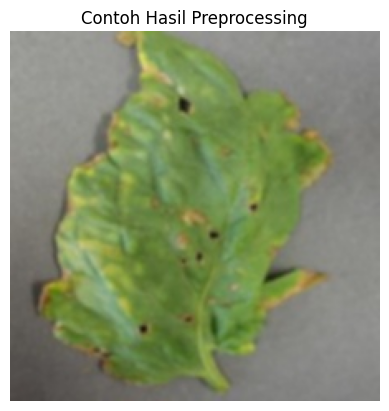

In [19]:
sample_class = os.listdir(TRAIN_OUT)[0]
sample_img = os.listdir(os.path.join(TRAIN_OUT, sample_class))[0]

img = cv2.imread(os.path.join(TRAIN_OUT, sample_class, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Contoh Hasil Preprocessing")
plt.axis("off")